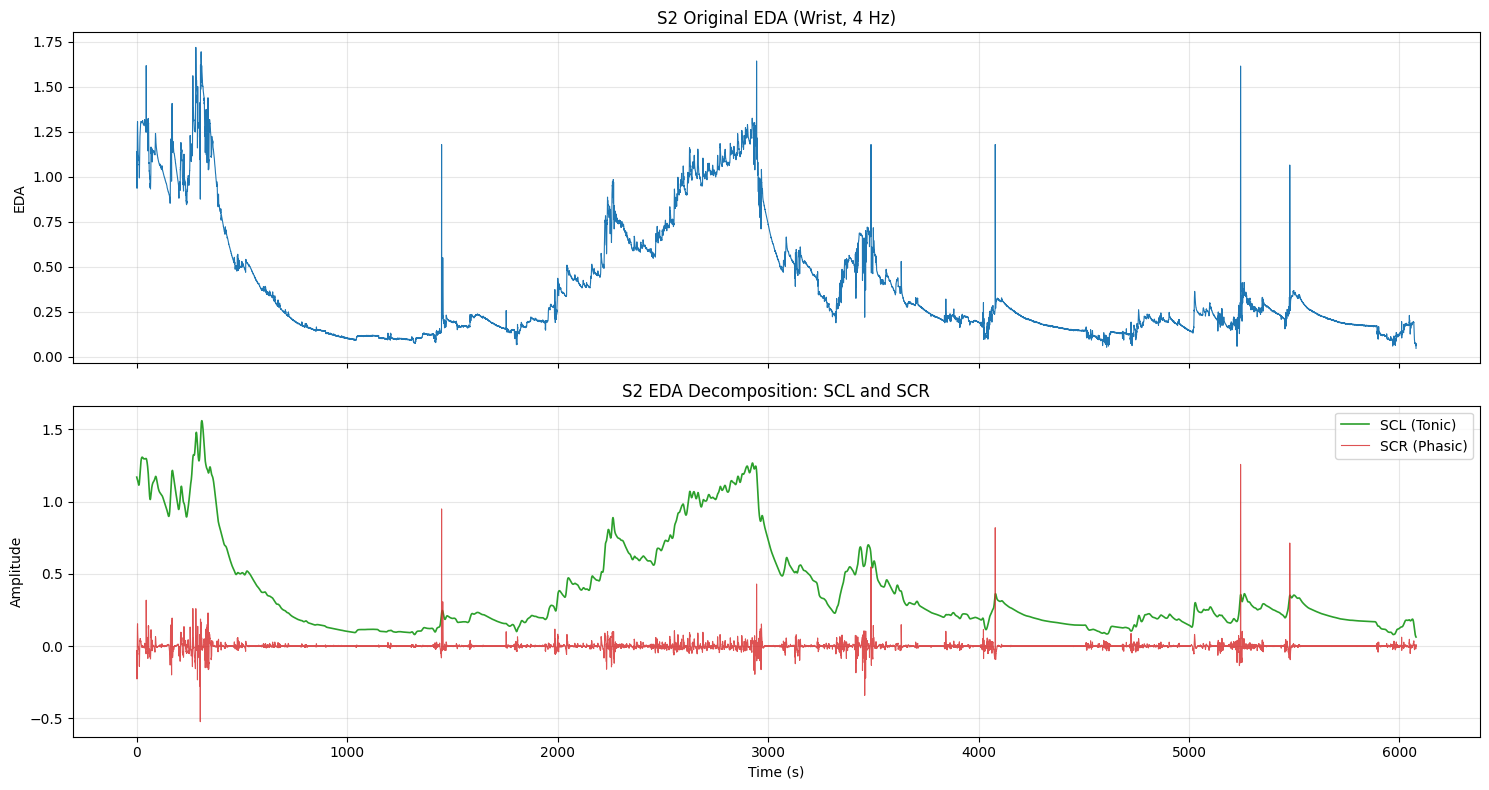

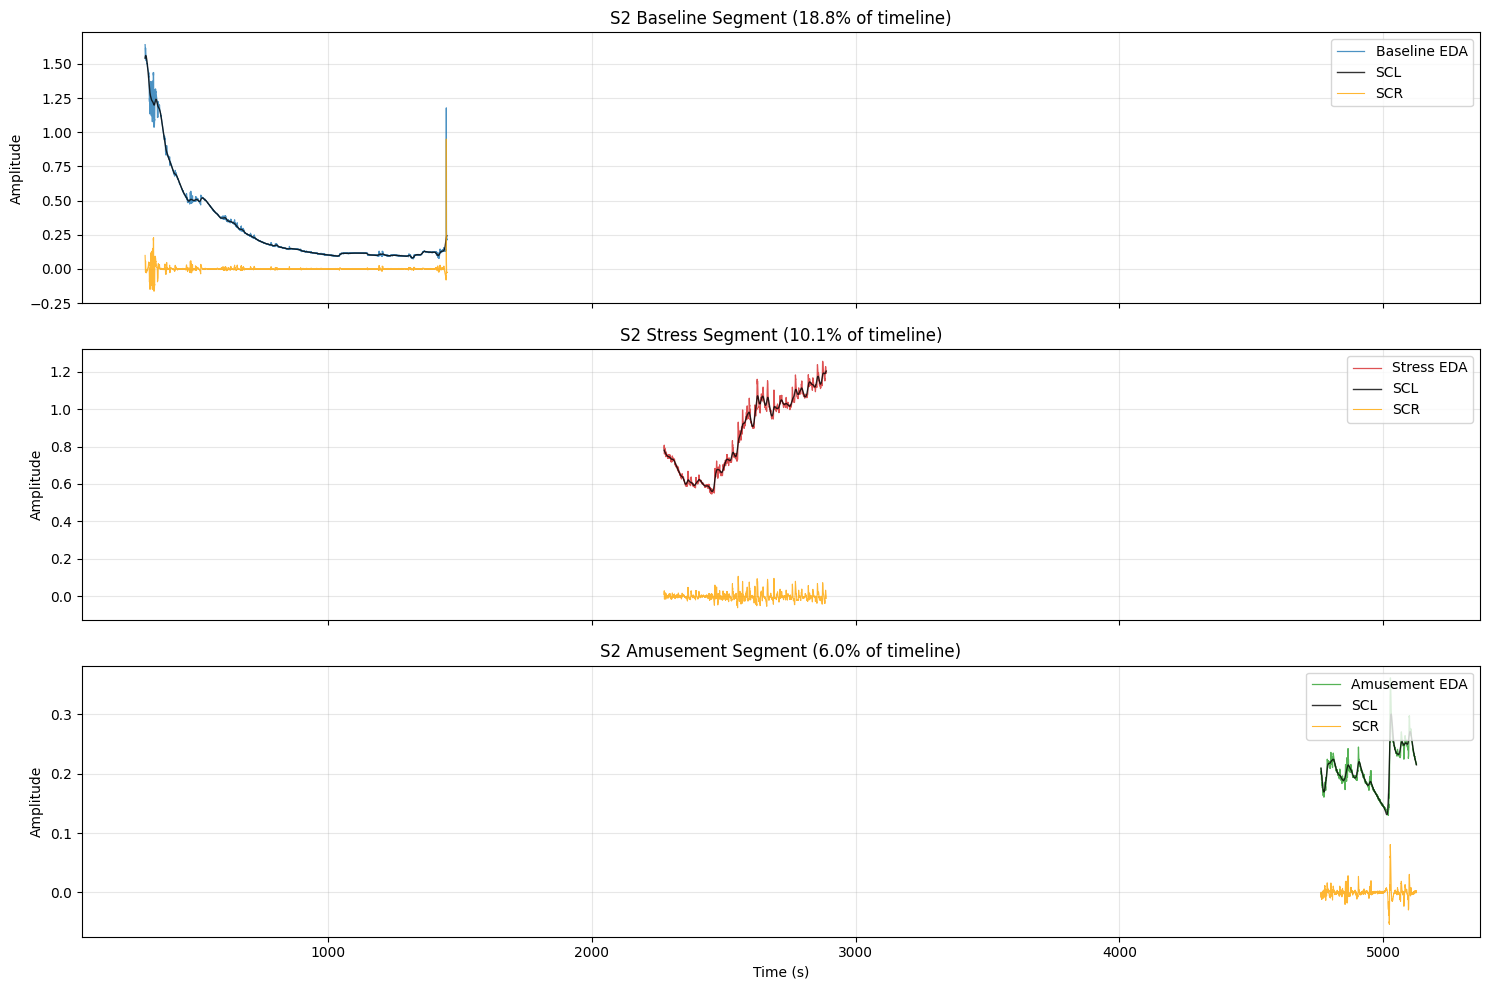

Dataset path: /home/binghin2/Myproject/Dataset/WESAD
S2 EDA samples: 24,316 | Duration: 101.3 min | Fs: 4 Hz
  - Baseline: 4,576 samples
  - Stress: 2,460 samples
  - Amusement: 1,448 samples


In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 1) WESAD S2 데이터 경로 찾기
candidates = [
    '../../../Dataset/WESAD',
    '../../Dataset/WESAD',
    '../Dataset/WESAD',
    '/home/binghin2/Myproject/Dataset/WESAD',
]

dataset_path = next((p for p in candidates if os.path.isdir(p)), None)
if dataset_path is None:
    raise FileNotFoundError(f'WESAD 폴더를 찾지 못했습니다. 확인한 경로: {candidates}')

s2_path = os.path.join(dataset_path, 'S2', 'S2.pkl')
if not os.path.isfile(s2_path):
    raise FileNotFoundError(f'S2.pkl 파일이 없습니다: {s2_path}')

# 2) S2 EDA 로드 (wrist EDA, 4 Hz)
with open(s2_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

eda = np.asarray(data['signal']['wrist']['EDA']).squeeze().astype(float)
fs = 4  # WESAD wrist EDA sampling rate
time = np.arange(len(eda)) / fs

# 3) EDA를 SCL(tonic) + SCR(phasic)로 단순 분해
# - SCL: 저역통과(0.05 Hz)
# - SCR: 원신호 - SCL
cutoff_hz = 0.05
nyq = 0.5 * fs
b, a = butter(N=2, Wn=cutoff_hz / nyq, btype='low')
scl = filtfilt(b, a, eda)
scr = eda - scl

# 4) label(700Hz)을 EDA 시간축(4Hz)으로 정렬
labels_700 = np.asarray(data['label']).squeeze().astype(float)
label_time = np.arange(len(labels_700)) / 700.0
labels_eda = np.rint(np.interp(time, label_time, labels_700)).astype(int)

label_map = {
    1: ('Baseline', 'tab:blue'),
    2: ('Stress', 'tab:red'),
    3: ('Amusement', 'tab:green'),
}

# 5) Plot A: 원본 EDA + SCL/SCR
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(time, eda, color='tab:blue', linewidth=0.8)
axes[0].set_title('S2 Original EDA (Wrist, 4 Hz)')
axes[0].set_ylabel('EDA')
axes[0].grid(alpha=0.3)

axes[1].plot(time, scl, color='tab:green', linewidth=1.2, label='SCL (Tonic)')
axes[1].plot(time, scr, color='tab:red', linewidth=0.8, alpha=0.8, label='SCR (Phasic)')
axes[1].set_title('S2 EDA Decomposition: SCL and SCR')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6) Plot B: 구간별(라벨별) EDA/SCL/SCR
fig2, axs = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for ax, lab in zip(axs, [1, 2, 3]):
    name, color = label_map[lab]
    mask = labels_eda == lab

    eda_seg = np.where(mask, eda, np.nan)
    scl_seg = np.where(mask, scl, np.nan)
    scr_seg = np.where(mask, scr, np.nan)

    ax.plot(time, eda_seg, color=color, linewidth=0.9, alpha=0.8, label=f'{name} EDA')
    ax.plot(time, scl_seg, color='black', linewidth=1.0, alpha=0.8, label='SCL')
    ax.plot(time, scr_seg, color='orange', linewidth=0.8, alpha=0.8, label='SCR')

    ratio = mask.mean() * 100
    ax.set_title(f'S2 {name} Segment ({ratio:.1f}% of timeline)')
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

axs[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

print(f'Dataset path: {os.path.abspath(dataset_path)}')
print(f'S2 EDA samples: {len(eda):,} | Duration: {len(eda)/fs/60:.1f} min | Fs: {fs} Hz')
for lab in [1, 2, 3]:
    print(f'  - {label_map[lab][0]}: {(labels_eda == lab).sum():,} samples')